In [1]:
#STEP 1-IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import re
import nltk
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# STEP 2 - VERIFY FOLDER
import os
print(os.getcwd())

c:\Users\moham\OneDrive\Desktop\FAKE_NEWS_DETECTION


In [3]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\moham\OneDrive\Desktop\FAKE_NEWS_DETECTION
['app.py', 'models', 'Naive_Bayes.ipynb', 'News _dataset', 'random_forest_model.pkl', 'RF.ipynb', 'SVM.ipynb', 'svm_model.pkl', 'tfidf_vectorizer.pkl', 'tfidf_vectorizer_rf.pkl', 'venv']


In [4]:
#STEP 3-LOAD DATASET
fake_path = "News _dataset/Fake.csv"
true_path = "News _dataset/True.csv"

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

# Add Labels
fake_df["label"] = 0   # Fake News
true_df["label"] = 1   # True News

# Combine dataset
data = pd.concat([fake_df, true_df])

# Shuffle dataset
data = data.sample(frac=1).reset_index(drop=True)

print("Dataset Loaded Successfully")
data.head()

Dataset Loaded Successfully


,title,text,subject,date,label
0,FORMER MEXICAN PRESIDENT Tries To ‘Make Nice’ ...,"If this is what s to come, IT S GOING TO BE AW...",politics,"May 4, 2016",0
1,Factbox: German coalition watch - Let's not be...,BERLIN (Reuters) - Chancellor Angela Merkel wo...,worldnews,"October 14, 2017",1
2,UNBELIEVABLE: OBAMA Stands Firm On Taking Rand...,This isn t the first time Obama left an import...,politics,"Nov 24, 2015",0
3,Austria puts the squeeze on refugees with bene...,"VIENNA (Reuters) - Ahmed Ali, a 34-year-old te...",worldnews,"October 4, 2017",1
4,The Internet Loses It Over RNC’s Bizarre Stat...,The Republican National Committee released a b...,News,"December 25, 2016",0


In [5]:
#STEP 4- DATASET SIZE CHECK
print("Fake News Samples:", fake_df.shape)
print("True News Samples:", true_df.shape)
print("Total Samples:", data.shape)

Fake News Samples: (23481, 5)
True News Samples: (21417, 5)
Total Samples: (44898, 5)


In [6]:
#STEP 5-TEXT CLEANING
stop_words = stopwords.words('english')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\n', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

data["text"] = data["text"].apply(clean_text)

data.head()

,title,text,subject,date,label
0,FORMER MEXICAN PRESIDENT Tries To ‘Make Nice’ ...,come going awesome vicente fox apologized trum...,politics,"May 4, 2016",0
1,Factbox: German coalition watch - Let's not be...,berlin reuters chancellor angela merkel fourth...,worldnews,"October 14, 2017",1
2,UNBELIEVABLE: OBAMA Stands Firm On Taking Rand...,first time obama left important figure behind ...,politics,"Nov 24, 2015",0
3,Austria puts the squeeze on refugees with bene...,vienna reuters ahmed ali year old teacher fled...,worldnews,"October 4, 2017",1
4,The Internet Loses It Over RNC’s Bizarre Stat...,republican national committee released bizarre...,News,"December 25, 2016",0


In [7]:
#STEP 6-TRAIN TEST SPLIT
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 35918
Testing Samples: 8980


In [8]:
#STEP 7- TF-IDF VECTORIZATION
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("TF-IDF Vectorization Completed")

TF-IDF Vectorization Completed


In [9]:
#STEP 8- TRAINING NAIVE BAYES MODEL
nb_model = MultinomialNB()

nb_model.fit(X_train_vec, y_train)

print("Naive Bayes Model Trained Successfully")
nb_model.fit

Naive Bayes Model Trained Successfully


<bound method _BaseDiscreteNB.fit of MultinomialNB()>

In [10]:
#STEP 9- PREDICTION
y_pred = nb_model.predict(X_test_vec)
statements = X_test.iloc[:10].tolist()
predictions = y_pred[:10]
for i, statement in enumerate(statements):
    result = "TRUE" if predictions[i] == 1 else "FAKE"
    print(f"Statement: {statement[:100]}...")
    print(f"Prediction: {result}\n")

Statement: fox business interview earlier day see gino defabio asked speak ohio rally president trump speaking ...
Prediction: FAKE

Statement: remember promise fence southern border yes plan billion dollar plan never executed proposed thank ob...
Prediction: FAKE

Statement: mexico city reuters mexico senate friday named country new top prosecutor election related crimes of...
Prediction: TRUE

Statement: washington reuters white house expects u congress soon waive rule known paygo could trigger deep spe...
Prediction: TRUE

Statement: sydney reuters year old remains aboriginal man prompted drastic rewrite australian history returned ...
Prediction: FAKE

Statement: robert slater wrote book called thing exposure inside life celebrity donald trump biography eventual...
Prediction: FAKE

Statement: last week president trump announced presidential proclamation sunday september would known national ...
Prediction: FAKE

Statement: let point laugh sad trump supporters realizing got totally

In [11]:
# USER PREDICTION BLOCK
# Paste your statement between the triple quotes below:
user_statement = """
As U.S. budget fight looms, Republicans flip their fiscal script","WASHINGTON (Reuters)
"""

def get_prediction(text):
    # 1. Clean the input text using the function from STEP 5
    cleaned_text = clean_text(text)
    
    # 2. Vectorize the cleaned text
    # Note: This uses the 'vectorizer' object created in STEP 7
    vec_text = vectorizer.transform([cleaned_text])
    
    # 3. Predict using the 'nb_model' from STEP 8
    prediction = nb_model.predict(vec_text)[0]
    
    # 4. Return result based on the labels in STEP 3 (0=Fake, 1=True)
    if prediction == 1:
        return "TRUE NEWS"
    else:
        return "FAKE NEWS"

# Run the prediction
result = get_prediction(user_statement)

print("-" * 30)
print(f"STATEMENT: {user_statement.strip()[:150]}...")
print(f"RESULT: {result}")
print("-" * 30)

------------------------------
STATEMENT: As U.S. budget fight looms, Republicans flip their fiscal script","WASHINGTON (Reuters)...
RESULT: TRUE NEWS
------------------------------


In [12]:
#STEP 10- ACCURACY
accuracy = accuracy_score(y_test, y_pred)

print("Naive Bayes Accuracy:", accuracy)

Naive Bayes Accuracy: 0.9316258351893095


In [13]:
#STEP 11- CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4643
           1       0.93      0.93      0.93      4337

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



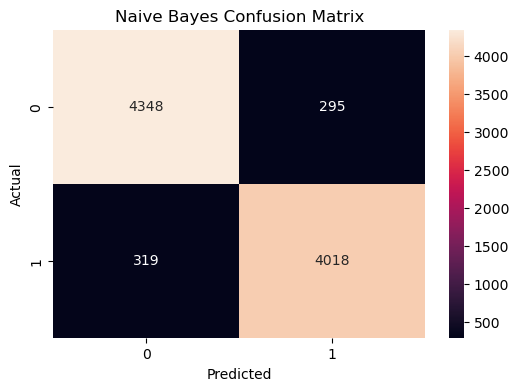

In [14]:
#STEP 12- CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [15]:
#SAVE MODEL
import os
import pickle

# Create models folder if it does not exist
os.makedirs("models", exist_ok=True)

# Save Naive Bayes model
with open("models/naive_bayes_model.pkl", "wb") as f:
    pickle.dump(nb_model, f)

# Save TF-IDF vectorizer
with open("models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model Saved Successfully")

Model Saved Successfully
